# Exploratory analysis

Análisis exploratorio del dataset de ventas. Este notebook carga los datos, muestra estadísticas básicas y hace visualizaciones con matplotlib/seaborn.

In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
# Seleccionar archivo a analizar: puedes editar FILE_PATH o usar la variable de entorno DATA_CSV.
import os, glob
FILE_PATH = os.environ.get('DATA_CSV')
if not FILE_PATH:
    files = sorted(glob.glob('../data/processed/*.csv'))
    if files:
        FILE_PATH = files[-1]  # por defecto usar el más reciente en processed
    else:
        FILE_PATH = '../data/raw/data.csv'  # fallback
print('Usando archivo:', FILE_PATH)
df = pd.read_csv(FILE_PATH, encoding='latin-1')
df.shape


Usando archivo: ../data/processed\data_2025-10-27.csv


(406829, 10)

In [4]:
# Primer vistazo
df.head()


,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,TotalPrice,CustomerID,Country,is_return
0,536365,2010-01-12 08:26:00,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,17850.0,United Kingdom,False
1,536365,2010-01-12 08:26:00,71053,WHITE METAL LANTERN,6,3.39,20.34,17850.0,United Kingdom,False
2,536365,2010-01-12 08:26:00,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,17850.0,United Kingdom,False
3,536365,2010-01-12 08:26:00,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,17850.0,United Kingdom,False
4,536365,2010-01-12 08:26:00,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,17850.0,United Kingdom,False


In [5]:
# Estadísticas descriptivas sobre precios y cantidades
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df[['UnitPrice','Quantity']].describe()

,UnitPrice,Quantity
count,406829.000000,406829.000000
mean,3.460471,12.061303
std,69.315162,248.693370
min,0.000000,-80995.000000
25%,1.250000,2.000000
50%,1.950000,5.000000
75%,3.750000,12.000000
max,38970.000000,80995.000000


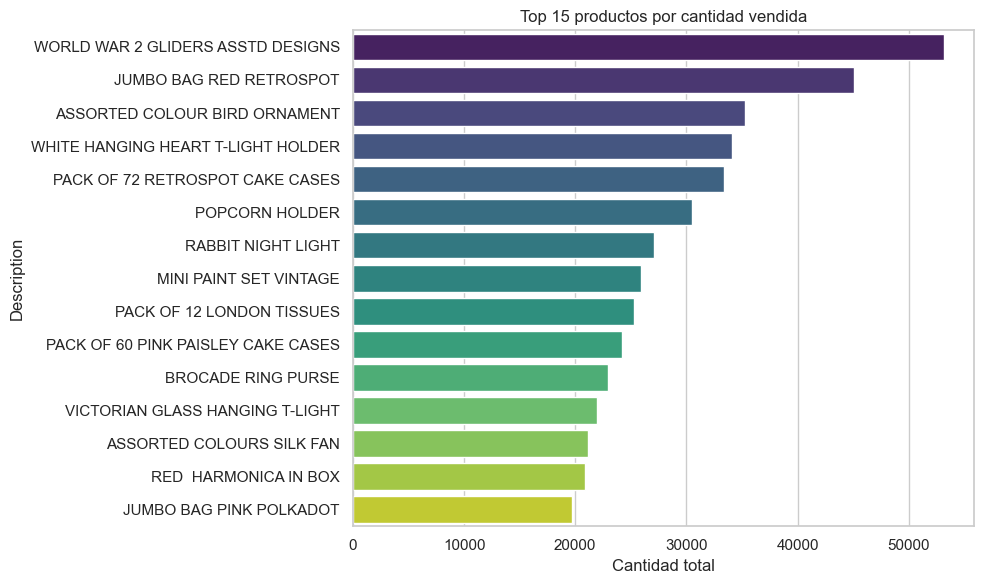

In [6]:
# Top 15 productos por cantidad total vendida
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 15 productos por cantidad vendida')
plt.xlabel('Cantidad total')
plt.tight_layout()
plt.show()

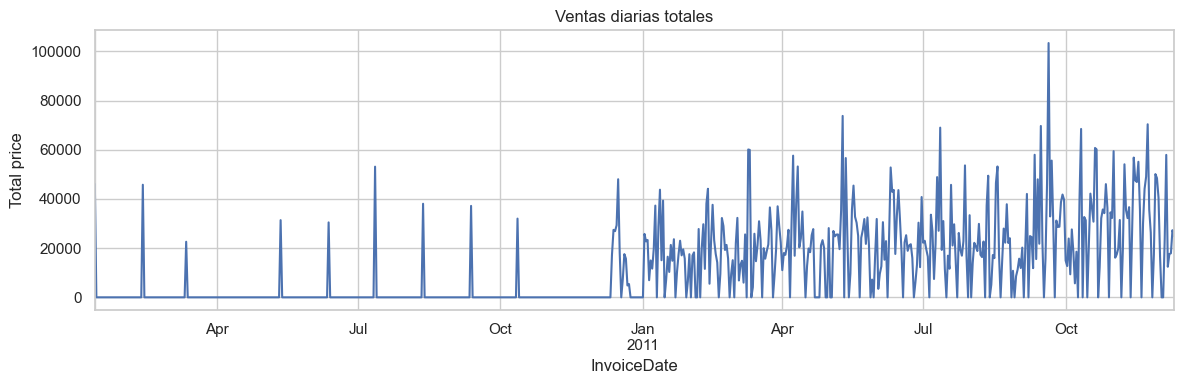

In [7]:
# Serie temporal: ventas totales por día
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
df['TotalPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce') * pd.to_numeric(df['Quantity'], errors='coerce')
daily = df.dropna(subset=['InvoiceDate']).set_index('InvoiceDate').resample('D')['TotalPrice'].sum()
plt.figure(figsize=(12,4))
daily.plot()
plt.title('Ventas diarias totales')
plt.ylabel('Total price')
plt.tight_layout()
plt.show()

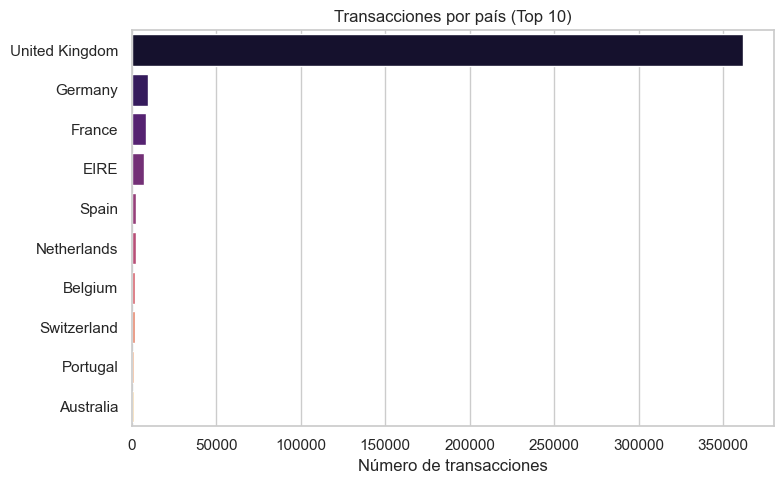

In [8]:
# Distribución por país (top 10)
countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=countries.values, y=countries.index, palette='magma')
plt.title('Transacciones por país (Top 10)')
plt.xlabel('Número de transacciones')
plt.tight_layout()
plt.show()